In [1]:
import pandas as pd

df = pd.read_csv(r'C:\WC26\data\results.csv')
df['date'] = pd.to_datetime(df['date'])

# keep post-2010 only — modern football is more relevant
df = df[df['date'] >= '2010-01-01'].reset_index(drop=True)

print(df.shape)
print(df.head())

(15889, 9)
        date home_team    away_team  home_score  away_score tournament  \
0 2010-01-02      Iran  North Korea         1.0         0.0   Friendly   
1 2010-01-02     Qatar         Mali         0.0         0.0   Friendly   
2 2010-01-02     Syria     Zimbabwe         6.0         0.0   Friendly   
3 2010-01-02     Yemen   Tajikistan         0.0         1.0   Friendly   
4 2010-01-03    Angola       Gambia         1.0         1.0   Friendly   

                         city   country  neutral  
0                        Doha     Qatar     True  
1                        Doha     Qatar    False  
2                Kuala Lumpur  Malaysia     True  
3                      Sana'a     Yemen    False  
4  Vila Real de Santo António  Portugal     True  


In [2]:
def get_outcome(row):
    if row['home_score'] > row['away_score']:
        return 2   # home win
    elif row['home_score'] < row['away_score']:
        return 0   # away win
    else:
        return 1   # draw

df['outcome'] = df.apply(get_outcome, axis=1)

In [3]:
from collections import defaultdict

elo_ratings = defaultdict(lambda: 1500)  # all teams start at 1500
K = 32  # update speed

def expected_score(ra, rb):
    return 1 / (1 + 10 ** ((rb - ra) / 400))

def update_elo(winner_elo, loser_elo, result, k=K):
    # result: 1 = win, 0.5 = draw, 0 = loss
    exp = expected_score(winner_elo, loser_elo)
    new = winner_elo + k * (result - exp)
    return round(new, 2)

elo_before_home = []
elo_before_away = []

df = df.sort_values('date').reset_index(drop=True)

for _, row in df.iterrows():
    h, a = row['home_team'], row['away_team']
    eh, ea = elo_ratings[h], elo_ratings[a]

    elo_before_home.append(eh)
    elo_before_away.append(ea)

    if row['outcome'] == 2:    # home win
        elo_ratings[h] = update_elo(eh, ea, 1)
        elo_ratings[a] = update_elo(ea, eh, 0)
    elif row['outcome'] == 0:  # away win
        elo_ratings[h] = update_elo(eh, ea, 0)
        elo_ratings[a] = update_elo(ea, eh, 1)
    else:                      # draw
        elo_ratings[h] = update_elo(eh, ea, 0.5)
        elo_ratings[a] = update_elo(ea, eh, 0.5)

df['elo_home'] = elo_before_home
df['elo_away'] = elo_before_away
df['elo_diff'] = df['elo_home'] - df['elo_away']

In [4]:
def recent_form(team, date, df, n=5):
    past = df[(df['date'] < date) & 
              ((df['home_team'] == team) | (df['away_team'] == team))].tail(n)
    points = 0
    for _, r in past.iterrows():
        if r['home_team'] == team:
            if r['outcome'] == 2: points += 3
            elif r['outcome'] == 1: points += 1
        else:
            if r['outcome'] == 0: points += 3
            elif r['outcome'] == 1: points += 1
    return points  # max 15

df['form_home'] = df.apply(lambda r: recent_form(r['home_team'], r['date'], df), axis=1)
df['form_away'] = df.apply(lambda r: recent_form(r['away_team'], r['date'], df), axis=1)
df['form_diff'] = df['form_home'] - df['form_away']

In [5]:
df['is_neutral'] = df['neutral'].astype(int)

tournament_weight = {
    'FIFA World Cup': 3,
    'UEFA Euro': 2,
    'Copa América': 2,
    'AFC Asian Cup': 2,
    'Friendly': 0.5,
}
df['tournament_weight'] = df['tournament'].map(tournament_weight).fillna(1)

In [6]:
df['avg_goals_home'] = df.groupby('home_team')['home_score'].transform(
    lambda x: x.shift().rolling(10, min_periods=1).mean()
)
df['avg_goals_away'] = df.groupby('away_team')['away_score'].transform(
    lambda x: x.shift().rolling(10, min_periods=1).mean()
)
df['avg_goals_diff'] = df['avg_goals_home'] - df['avg_goals_away']

# update features list
features = ['elo_diff', 'form_diff', 'is_neutral', 'tournament_weight', 'avg_goals_diff']

In [7]:
# 1. Head to head record (last 5 meetings)
def h2h_wins(home, away, date, df, n=5):
    past = df[
        (df['date'] < date) & (
            ((df['home_team']==home) & (df['away_team']==away)) |
            ((df['home_team']==away) & (df['away_team']==home))
        )
    ].tail(n)
    wins = 0
    for _, r in past.iterrows():
        if (r['home_team']==home and r['outcome']==2) or \
           (r['away_team']==home and r['outcome']==0):
            wins += 1
    return wins

# 2. Tournament stage pressure (group stage vs knockouts)
stage_map = {
    'FIFA World Cup': 3, 'UEFA Euro': 3, 'Copa América': 3,
    'UEFA Nations League': 2, 'Friendly': 0
}
df['is_major_tournament'] = df['tournament'].map(stage_map).fillna(1).astype(int)

# 3. Goals conceded defensiveness rating
df['avg_conceded_home'] = df.groupby('home_team')['away_score'].transform(
    lambda x: x.shift().rolling(10, min_periods=1).mean()
)
df['avg_conceded_away'] = df.groupby('away_team')['home_score'].transform(
    lambda x: x.shift().rolling(10, min_periods=1).mean()
)
df['defense_diff'] = df['avg_conceded_away'] - df['avg_conceded_home']  # positive = home team better defense

# h2h is slow, compute separately
df['h2h_home_wins'] = df.apply(
    lambda r: h2h_wins(r['home_team'], r['away_team'], r['date'], df), axis=1
)

In [8]:
features = [
    'elo_diff', 'form_diff', 'is_neutral', 'tournament_weight',
    'avg_goals_diff', 'defense_diff', 'is_major_tournament', 'h2h_home_wins'
]
target = 'outcome'

df[features + [target, 'date', 'home_team', 'away_team']].to_csv(r'C:\WC26\data\wc_features.csv', index=False)
print("Done. Shape:", df.shape)
print(df[features].describe())

Done. Shape: (15889, 26)
           elo_diff     form_diff    is_neutral  tournament_weight  \
count  15889.000000  15889.000000  15889.000000       15889.000000   
mean      14.214421      0.214740      0.307131           0.914375   
std      151.155995      4.732239      0.461319           0.433358   
min     -837.680000    -15.000000      0.000000           0.500000   
25%      -69.810000     -3.000000      0.000000           0.500000   
50%       13.200000      0.000000      0.000000           1.000000   
75%       97.940000      3.000000      1.000000           1.000000   
max      775.790000     15.000000      1.000000           3.000000   

       avg_goals_diff  defense_diff  is_major_tournament  h2h_home_wins  
count    15409.000000  15409.000000         15889.000000   15889.000000  
mean         0.494418      0.499971             0.807980       0.656555  
std          0.901402      1.053087             0.703946       1.002101  
min        -10.222222    -17.666667             

Phase - 02

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv(r'C:\WC26\data\wc_features.csv')

features = [
    'elo_diff', 'form_diff', 'is_neutral', 'tournament_weight',
    'avg_goals_diff', 'defense_diff', 'is_major_tournament', 'h2h_home_wins'
]
X = df[features].fillna(0)  # 0 = no history available, sensible default
y = df['outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.isna().sum())  # should be all zeros now

print(X_train.shape, X_test.shape)
print(y.value_counts(normalize=True))  # check class balance

elo_diff               0
form_diff              0
is_neutral             0
tournament_weight      0
avg_goals_diff         0
defense_diff           0
is_major_tournament    0
h2h_home_wins          0
dtype: int64
(12711, 8) (3178, 8)
outcome
2    0.477437
0    0.288690
1    0.233872
Name: proportion, dtype: float64


Baseline model (Logistic Regression)

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Baseline accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, target_names=['Away Win','Draw','Home Win']))

Baseline accuracy: 0.5641913152926369
              precision    recall  f1-score   support

    Away Win       0.52      0.56      0.54       918
        Draw       0.00      0.00      0.00       743
    Home Win       0.58      0.85      0.69      1517

    accuracy                           0.56      3178
   macro avg       0.37      0.47      0.41      3178
weighted avg       0.43      0.56      0.49      3178



c:\WC26\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\WC26\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\WC26\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


XGBoost

In [19]:
from xgboost import XGBClassifier

# count class weights
from sklearn.utils.class_weight import compute_sample_weight
weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb_final = XGBClassifier(
    learning_rate=0.05,
    max_depth=3,
    n_estimators=100,     
    subsample=0.7,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42
)

xgb_final.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)],sample_weight=weights)

y_pred = xgb_final.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['Away Win','Draw','Home Win']))

[0]	validation_0-mlogloss:1.08991	validation_1-mlogloss:1.09030


[1]	validation_0-mlogloss:1.08155	validation_1-mlogloss:1.08243
[2]	validation_0-mlogloss:1.07372	validation_1-mlogloss:1.07510
[3]	validation_0-mlogloss:1.06800	validation_1-mlogloss:1.06986
[4]	validation_0-mlogloss:1.06223	validation_1-mlogloss:1.06464
[5]	validation_0-mlogloss:1.05706	validation_1-mlogloss:1.06002
[6]	validation_0-mlogloss:1.05231	validation_1-mlogloss:1.05572
[7]	validation_0-mlogloss:1.04752	validation_1-mlogloss:1.05123
[8]	validation_0-mlogloss:1.04328	validation_1-mlogloss:1.04732
[9]	validation_0-mlogloss:1.03908	validation_1-mlogloss:1.04351
[10]	validation_0-mlogloss:1.03399	validation_1-mlogloss:1.03870
[11]	validation_0-mlogloss:1.03033	validation_1-mlogloss:1.03538
[12]	validation_0-mlogloss:1.02596	validation_1-mlogloss:1.03126
[13]	validation_0-mlogloss:1.02179	validation_1-mlogloss:1.02743
[14]	validation_0-mlogloss:1.01787	validation_1-mlogloss:1.02369
[15]	validation_0-mlogloss:1.01518	validation_1-mlogloss:1.02118
[16]	validation_0-mlogloss:1.01166

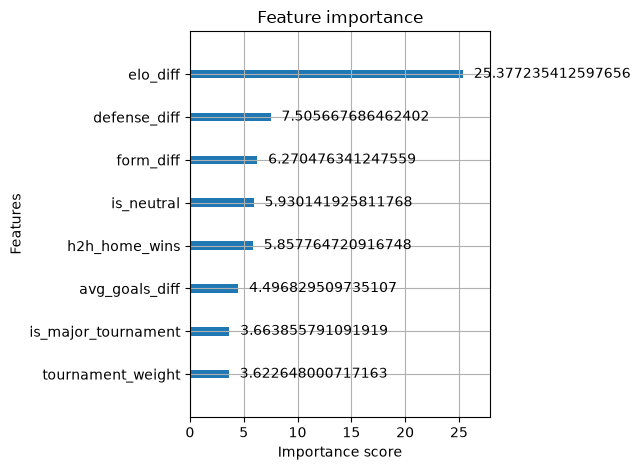

In [20]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(xgb_final, importance_type='gain')
plt.tight_layout()
plt.show()

In [22]:
# you want probabilities, not just class labels
probs = xgb_final.predict_proba(X_test)
print(probs[:5])  # [away_win%, draw%, home_win%] for each match

[[0.45721558 0.32736596 0.21541843]
 [0.07355303 0.164487   0.76195997]
 [0.30238923 0.35176808 0.3458427 ]
 [0.74913764 0.13083538 0.12002702]
 [0.5245225  0.34216025 0.13331725]]


In [26]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [200, 400, 600],   # was capped at 200
    'subsample': [0.7, 0.8],
}

xgb_es = XGBClassifier(
    learning_rate=0.05,
    max_depth=4,
    subsample=0.7,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    early_stopping_rounds=30,    
    n_estimators=1000,          
    random_state=42
)

xgb_es.fit(
    X_train, y_train,
    sample_weight=weights,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print("Best round:", xgb_es.best_iteration)
print("Best score:", xgb_es.best_score)

y_pred = xgb_es.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Away Win','Draw','Home Win']))

[0]	validation_0-mlogloss:1.08995
[50]	validation_0-mlogloss:0.97120
[100]	validation_0-mlogloss:0.96447
[130]	validation_0-mlogloss:0.96503
Best round: 100
Best score: 0.9644716736960798
              precision    recall  f1-score   support

    Away Win       0.51      0.60      0.55       918
        Draw       0.29      0.32      0.30       743
    Home Win       0.69      0.57      0.62      1517

    accuracy                           0.52      3178
   macro avg       0.49      0.50      0.49      3178
weighted avg       0.54      0.52      0.53      3178



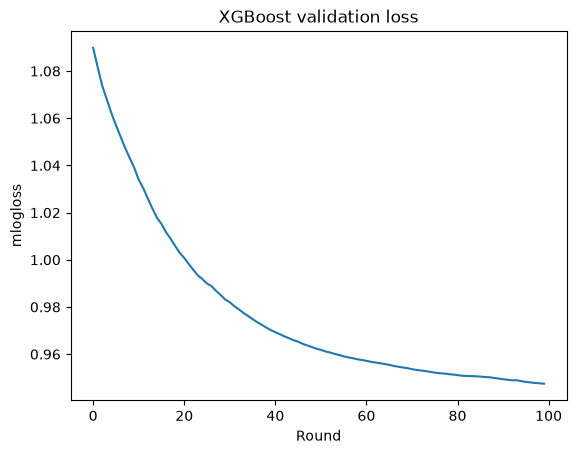

In [29]:
results = xgb_final.evals_result()
plt.plot(results['validation_0']['mlogloss'])
plt.xlabel('Round')
plt.ylabel('mlogloss')
plt.title('XGBoost validation loss')
plt.show()
# if it bottoms out at round ~80-100, set n_estimators to that

In [33]:
import joblib

# save with best iteration baked in
joblib.dump(xgb_final, r'C:\WC26\models\xgb_model.pkl')
print("Saved. Best round:", xgb_es.best_iteration)

# verify
model = joblib.load(r'C:\WC26\models\xgb_model.pkl')

# test prediction — Argentina vs South Africa
test_input = pd.DataFrame([{
    'elo_diff': 350,        # Argentina much stronger
    'form_diff': 6,
    'is_neutral': 1,
    'tournament_weight': 3,
    'avg_goals_diff': 0.8,
    'defense_diff': 0.5,
    'is_major_tournament': 3,
    'h2h_home_wins': 3
}])

probs = model.predict_proba(test_input)[0]
print(f"Away win: {probs[0]:.0%}")
print(f"Draw:     {probs[1]:.0%}")
print(f"Home win: {probs[2]:.0%}")

Saved. Best round: 100
Away win: 8%
Draw:     42%
Home win: 50%
